# RQ1: Baseline Model Performance
This section evaluates baseline machine learning models to understand their initial performance on the dataset.


In [10]:
import os
os.listdir('/kaggle/input')

['notebooks', 'datasets']

In [11]:
os.listdir('/kaggle/input/datasets')

['imranalishahh']

In [12]:
os.listdir('/kaggle/input/datasets/imranalishahh')

['marketing-and-product-performance-dataset']

In [13]:
os.listdir('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset')

['marketing_and_product_performance.csv']

In [14]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [17]:
# create classification target
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [18]:
df[["Revenue_Generated", "Target"]].head()

,Revenue_Generated,Target
0,15520.09,0
1,30866.17,0
2,32585.62,0
3,95740.12,1
4,81990.43,1


In [ ]:
# drop original revenue column safely
df = df.drop(columns=["Revenue_Generated"], errors='ignore')

# fill missing values
df = df.fillna(df.mean(numeric_only=True))

# convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# reduce dataset size
df = df.sample(2000, random_state=42)

df.head()

,Budget,Clicks,Conversions,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Target,...,Bundle_ID_BNDL_ZZHJ0V,Bundle_ID_BNDL_ZZL4GJ,Bundle_ID_BNDL_ZZN9RX,Bundle_ID_BNDL_ZZOB89,Bundle_ID_BNDL_ZZWGC1,Bundle_ID_BNDL_ZZXSRS,Bundle_ID_BNDL_ZZYTXF,Common_Keywords_Durable,Common_Keywords_Innovative,Common_Keywords_Stylish
6252,25841.57,2510,209,2.83,5,26,65,122.08,3,1,...,False,False,False,False,False,False,False,False,False,True
4684,34011.37,3250,452,4.59,22,64,150,411.35,1,1,...,False,False,False,False,False,False,False,False,True,False
1731,17631.30,3535,248,4.68,35,68,82,479.01,3,1,...,False,False,False,False,False,False,False,True,False,False
4742,8274.09,3907,340,0.70,5,17,133,87.99,4,1,...,False,False,False,False,False,False,False,False,False,False
4521,20042.17,4047,915,3.42,21,29,47,352.01,1,0,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

In [ ]:
import pandas as pd

table = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])

table

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.4890,0.498894,0.442157,0.468815
1,Decision Tree,0.4995,0.509567,0.496078,0.502732


['RQ1_figure.pdf', '.virtual_documents', 'RQ1_table.csv']

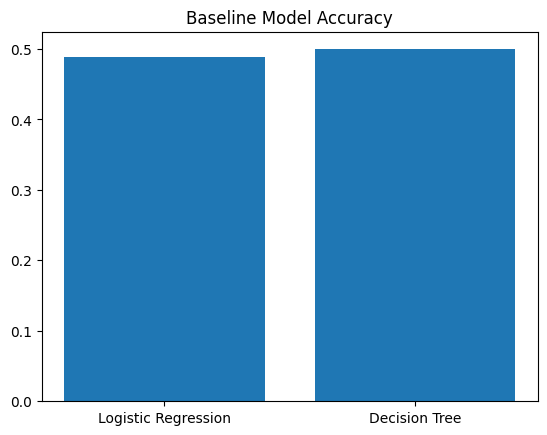

In [30]:
import os
import matplotlib.pyplot as plt

# save table
table.to_csv("/kaggle/working/RQ1_table.csv", index=False)

# save figure again
plt.figure()
plt.bar(table["Model"], table["Accuracy"])
plt.title("Baseline Model Accuracy")
plt.savefig("/kaggle/working/RQ1_figure.pdf")

# check files
os.listdir('/kaggle/working')

In [ ]:
plt.show()

## Results Interpretation

The baseline models show moderate performance, indicating that the dataset contains useful patterns but is not easily separable. This suggests that more advanced models may improve performance.